## Entrenamiento de modelo de ML 

La idea es poder generar varios entrenamientos de 2 maneras de supervision (supervizado o no supervisado).  Veremos como se transforman y actua. 

## Entrenamiento no supervizado (IsolationForest)

se realiza un entrenamiento basico. 


In [2]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np

def cargar(bit):
    """Lee el CSV generado en el notebook 05 para un bit dado."""
    df = pd.read_csv(f'../data/processed/cca_o3_bit{bit:02d}_tasa05.csv',
                     parse_dates=['timestamp'])
    return df[df.received_value.notna()].copy()


def features(df, con_hora=True):
    """Construye la matriz de entrada del modelo.

    Solo received_value y hora. NUNCA original_value, bit, daño ni
    atacado: esas son verdad de campo, no informacion disponible en
    produccion.
    """
    X = pd.DataFrame(index=df.index)
    v = df.received_value
    X['valor_log'] = np.sign(v) * np.log1p(np.abs(v))
    if con_hora:
        X['hora_sin'] = np.sin(2*np.pi*df.hora/24)
        X['hora_cos'] = np.cos(2*np.pi*df.hora/24)
    return X

In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score

res = []
for bit in range(13):
    df = cargar(bit)
    X = features(df, con_hora=True)
    y = df.atacado.values          # SOLO para evaluar, nunca para entrenar

    modelo = IsolationForest(contamination=0.05, random_state=42)
    pred = (modelo.fit_predict(X) == -1).astype(int)

    res.append({
        'bit': bit,
        'delta_ppb': 2**bit,
        'recall_%': round(recall_score(y, pred)*100, 1),
        'precision_%': round(precision_score(y, pred, zero_division=0)*100, 1),
        'fp': int(((pred==1) & (y==0)).sum()),
    })

pd.DataFrame(res)

,bit,delta_ppb,recall_%,precision_%,fp
0,0,1,5.1,5.0,323
1,1,2,11.4,11.2,302
2,2,4,6.9,6.8,316
3,3,8,7.8,7.8,308
4,4,16,12.3,12.1,297
5,5,32,18.6,18.2,278
6,6,64,43.7,45.1,178
7,7,128,79.9,78.5,73
8,8,256,89.8,90.4,32
9,9,512,100.0,98.2,6


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier
from src.attack.blind import generar_dataset
from src.ingest.rama import load_wide, to_long, chronological_split

# Dataset SIN ataques
long = to_long(load_wide('../data/raw/2025O3.xls'), 'O3')
cca = long[long.station == 'CCA'].reset_index(drop=True)
train, _ = chronological_split(cca)

limpio = generar_dataset(train, bit=5, tasa=0.0)
limpio = limpio[limpio.received_value.notna()]

X = features(limpio)
y = limpio.atacado.values

print(f"Filas: {len(X)}   ataques reales: {y.sum()}")

# No supervisado
iso = IsolationForest(contamination=0.05, random_state=42)
pred_iso = (iso.fit_predict(X) == -1).astype(int)
print(f"\nIsolationForest marcó: {pred_iso.sum()} mensajes")
print(f"  → todos son falsos positivos ({pred_iso.sum()/len(X)*100:.1f}% del total)")

# Supervisado: no se puede entrenar sin ejemplos positivos
print("\nSupervisado: no aplicable. Sin ataques en el conjunto de")
print("entrenamiento no hay clase positiva que aprender.")

Filas: 6788   ataques reales: 0

IsolationForest marcó: 340 mensajes
  → todos son falsos positivos (5.0% del total)

Supervisado: no aplicable. Sin ataques en el conjunto de
entrenamiento no hay clase positiva que aprender.


In [8]:
marcados = limpio[pred_iso == 1]

print("Falsos positivos por hora del día:")
print(marcados.hora.value_counts().sort_index().to_string())

print(f"\nValor de los marcados:  media {marcados.received_value.mean():.1f} ppb")
print(f"Valor de los NO marcados: media {limpio[pred_iso==0].received_value.mean():.1f} ppb")

Falsos positivos por hora del día:
hora
0     26
1      4
2     20
3     26
4     25
5      2
6     14
8     17
9      5
10     4
11     4
12    15
13    12
14    15
15    28
16    25
17     9
18    17
19    14
20    26
21    26
22     3
23     3

Valor de los marcados:  media 31.7 ppb
Valor de los NO marcados: media 36.1 ppb


In [9]:
perfil = limpio.groupby('hora')['received_value'].mean()

m = limpio[pred_iso == 1].copy()
nm = limpio[pred_iso == 0].copy()

m['desvio'] = m.received_value - m.hora.map(perfil)
nm['desvio'] = nm.received_value - nm.hora.map(perfil)

print(f"Desvío de los marcados:     {m.desvio.abs().mean():.1f} ppb")
print(f"Desvío de los NO marcados:  {nm.desvio.abs().mean():.1f} ppb")

Desvío de los marcados:     30.2 ppb
Desvío de los NO marcados:  11.6 ppb


In [11]:
limpio = limpio.copy()
limpio['pred'] = pred_iso
limpio['mes'] = limpio.timestamp.dt.month

tabla = limpio.groupby('mes').agg(
    total=('pred', 'size'),
    fp=('pred', 'sum'),
)
tabla['tasa_fp_%'] = (tabla.fp / tabla.total * 100).round(2)

print(tabla.to_string())

     total  fp  tasa_fp_%
mes                      
1      725  57       7.86
2      654  37       5.66
3      725  42       5.79
4      694  18       2.59
5      729  20       2.74
6      691  72      10.42
7      726   8       1.10
8      707  30       4.24
9      690  23       3.33
10     447  33       7.38


In [12]:
perfil_h = limpio.groupby('hora')['received_value'].mean()
limpio['desvio'] = (limpio.received_value - limpio.hora.map(perfil_h)).abs()

print(limpio.groupby('mes').agg(
    media_ppb=('received_value', 'mean'),
    std_ppb=('received_value', 'std'),
    desvio_medio=('desvio', 'mean'),
    tasa_fp=('pred', lambda s: s.mean()*100),
).round(2).to_string())

     media_ppb  std_ppb  desvio_medio  tasa_fp
mes                                           
1        29.72    27.45         12.30     7.86
2        36.00    30.97         10.60     5.66
3        40.29    33.60         11.09     5.79
4        47.43    31.67         14.60     2.59
5        45.99    31.60         15.30     2.74
6        27.27    26.20         16.24    10.42
7        34.60    27.02         10.71     1.10
8        34.06    29.61         10.06     4.24
9        31.58    29.39         11.47     3.33
10       29.67    27.39         13.51     7.38


## Falsos positivos sobre datos sin ataques

### Objetivo

Jaime solicitó verificar el comportamiento del detector sobre tráfico
legítimo: *«que te diga "alguien alteró" y tú digas "ni siquiera lo he
tocado"»*. Sin esa medición no es posible distinguir cuánto de lo
detectado en los experimentos anteriores es señal y cuánto es ruido.

Se generó un dataset con `tasa=0.0`: ningún mensaje alterado.

### Resultado global

**340 falsos positivos sobre 6,788 mensajes legítimos (5.01%).**

El valor no es casual. `contamination=0.05` obliga al IsolationForest a
marcar exactamente el 5% de las observaciones, exista o no un ataque. En
ausencia de ataques, ese 5% son necesariamente falsos positivos.

Esto constituye una limitación estructural del enfoque: el parámetro
`contamination` requiere conocer de antemano la tasa de anomalía, que en
producción es desconocida.

**El clasificador supervisado no es aplicable en este escenario.** Sin
ejemplos positivos en el conjunto de entrenamiento no existe clase que
aprender. Es una diferencia estructural entre ambos enfoques.

### Qué marca el detector

| | Desvío respecto al perfil horario |
|---|---|
| Mensajes marcados | 30.2 ppb |
| Mensajes no marcados | 11.6 ppb |

Los marcados se apartan casi tres veces más del valor típico de su hora.

Esto confirma que el modelo utiliza efectivamente las características
`hora_sin` y `hora_cos`: no marca valores extremos en términos absolutos
—de hecho la media de los marcados (31.7 ppb) es *inferior* a la de los
no marcados (36.1 ppb)— sino valores incongruentes con la hora del día.

### Hallazgo: la tasa de falsos positivos depende del mes

| Mes | Media (ppb) | σ | Tasa FP |
|---|---|---|---|
| Junio | 27.27 | 26.20 | **10.42%** |
| Enero | 29.72 | 27.45 | 7.86% |
| Octubre | 29.67 | 27.39 | 7.38% |
| Marzo | 40.29 | 33.60 | 5.79% |
| Febrero | 36.00 | 30.97 | 5.66% |
| Agosto | 34.06 | 29.61 | 4.24% |
| Septiembre | 31.58 | 29.39 | 3.33% |
| Mayo | 45.99 | 31.60 | 2.74% |
| Abril | 47.43 | 31.67 | 2.59% |
| Julio | 34.60 | 27.02 | **1.10%** |

*Sobre el conjunto de entrenamiento (enero a octubre). Noviembre y
diciembre quedan fuera por corresponder al conjunto de prueba.*

**La tasa varía por un factor de 9.5 entre el mes más alto y el más
bajo.**

### Interpretación

La tasa de falsos positivos **no correlaciona con la desviación estándar**
del mes: junio presenta la menor σ (26.20) y la mayor tasa de FP (10.42%).

Correlaciona con la **media**: los tres meses de menor concentración
media (junio 27.27, octubre 29.67, enero 29.72) figuran entre los cuatro
de mayor tasa de FP, mientras que los dos de mayor media (abril 47.43,
mayo 45.99) presentan las tasas más bajas.

La explicación es estructural. El IsolationForest aprende un perfil
horario **global**, promediado sobre todo el periodo, y no dispone de
información de estacionalidad. Un mes cuya distribución se desplaza
respecto a ese perfil produce desviaciones sistemáticas que el modelo
interpreta como anomalías individuales.

**El detector confunde variación estacional con manipulación.**

Julio constituye una excepción parcial (media intermedia, tasa mínima)
que no queda explicada por este mecanismo. Queda como pendiente.

### Implicaciones

1. **La evaluación sobre un único periodo no es representativa.** Con un
   corte cronológico 80/20, el conjunto de prueba corresponde a noviembre
   y diciembre. Dada la variación observada, el desempeño medido sobre
   ese periodo no puede extrapolarse al año completo. Esto justifica
   la validación cruzada temporal.

2. **Se requiere contexto temporal más allá de la hora del día.** Un
   perfil horario global es insuficiente: el modelo necesita capturar la
   tendencia local, sea mediante una característica de estacionalidad o
   mediante un modelo con memoria.

3. **El parámetro `contamination` es una limitación práctica.** Fija la
   tasa de detección de antemano, independientemente de que exista o no
   manipulación.

### Hipótesis descartada

Se consideró que el descenso de junio pudiera deberse a la reducción de
tráfico vehicular por periodo vacacional. El calendario escolar mexicano
sitúa las vacaciones entre mediados de julio y mediados de agosto: junio
es mes lectivo completo, y julio y agosto presentan concentraciones
medias **superiores** a junio. La hipótesis no se sostiene.

La explicación más plausible es el inicio de la temporada de lluvias en
el Valle de México, que reduce la formación fotoquímica por menor
radiación e incrementa la dispersión y el lavado atmosférico. La
verificación requeriría datos de la red meteorológica REDMET y queda
fuera del alcance de este trabajo: la causa física del mes atípico es
secundaria frente a su consecuencia sobre el detector.

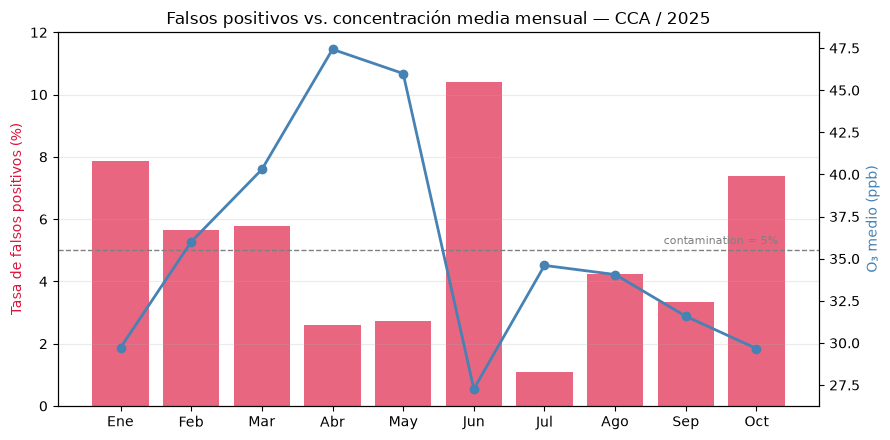

In [13]:
import matplotlib.pyplot as plt

t = tabla.copy()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct']

fig, ax1 = plt.subplots(figsize=(9, 4.5))

ax1.bar(range(len(t)), t['tasa_fp_%'], color='crimson', alpha=0.65,
        label='Tasa de falsos positivos')
ax1.axhline(5.0, ls='--', c='gray', lw=1)
ax1.text(9.3, 5.2, 'contamination = 5%', fontsize=8, c='gray', ha='right')
ax1.set_ylabel('Tasa de falsos positivos (%)', color='crimson')
ax1.set_xticks(range(len(t)))
ax1.set_xticklabels(meses)
ax1.set_ylim(0, 12)

ax2 = ax1.twinx()
medias = limpio.groupby('mes')['received_value'].mean()
ax2.plot(range(len(t)), medias.values, 'o-', color='steelblue', lw=2,
         label='O₃ medio del mes')
ax2.set_ylabel('O₃ medio (ppb)', color='steelblue')

ax1.set_title('Falsos positivos vs. concentración media mensual — CCA / 2025')
ax1.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('../docs/img/fp_por_mes.png', dpi=150)
plt.show()

In [14]:
res = []

# Sin ataques (ya lo tienes)
res.append({'escenario': 'sin ataques', 'fp': int(pred_iso.sum()),
            'ataques': 0, 'detectados': 0})

# Con ataques, por bit
for bit in [3, 5, 6, 9]:
    df = cargar(bit)
    X, y = features(df), df.atacado.values
    p = (IsolationForest(contamination=0.05, random_state=42)
         .fit_predict(X) == -1).astype(int)
    res.append({
        'escenario': f'bit {bit}',
        'fp': int(((p == 1) & (y == 0)).sum()),
        'ataques': int(y.sum()),
        'detectados': int(((p == 1) & (y == 1)).sum()),
    })

pd.DataFrame(res)

,escenario,fp,ataques,detectados
0,sin ataques,340,0,0
1,bit 3,308,334,26
2,bit 5,278,334,62
3,bit 6,178,334,146
4,bit 9,6,334,334
